# 🫀 Decision Tree — Cardiovascular Disease Prediction (v2)
### Improvements applied in this version
1. **max_depth constrained to ≤ 10** — prevents overfitting seen in Loss-vs-Depth curve
2. **Cost-Complexity Pruning (`ccp_alpha`)** — post-pruning to further reduce overfitting
3. **Threshold raised to 0.45–0.50** — reduces false positives while keeping recall high

### Pipeline
Mount Drive → Libraries → Load → Preprocess → Split → Scale → Grid Search → Pruning → Threshold Tune → Evaluate → Plots → Save

## 📁 Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Step 2 — Import Libraries

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, log_loss
)

print('All libraries imported ✅')

All libraries imported ✅


## 🗂️ Step 3 — Define Paths

In [3]:
DATASET_PATH = '/content/drive/MyDrive/ML_Assignment/DecisionTree/Dataset/cardio_train.csv'
RESULTS_DIR  = '/content/drive/MyDrive/ML_Assignment/DecisionTree/Results_v2'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results → {RESULTS_DIR}')

Results → /content/drive/MyDrive/ML_Assignment/DecisionTree/Results_v2


## 📊 Step 4 — Load Dataset

In [4]:
df = pd.read_csv(DATASET_PATH, sep=';')
print('Original shape :', df.shape)
print('Duplicate rows :', df.duplicated().sum())
df.head()

Original shape : (70000, 13)
Duplicate rows : 0


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 🔧 Step 5 — Preprocessing & Feature Engineering
- Remove duplicates, drop `id`
- Convert age from days → years
- Filter impossible blood pressure / height / weight values
- Engineer **BMI** and **Pulse Pressure**

In [5]:
df = df.drop_duplicates()
if 'id' in df.columns:
    df = df.drop('id', axis=1)

df['age'] = df['age'] / 365.25

df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 240)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 160)]
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30)  & (df['weight'] <= 200)]

df['bmi']            = df['weight'] / ((df['height'] / 100) ** 2)
df['bmi']            = df['bmi'].clip(10, 60)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

print('Shape after preprocessing:', df.shape)
df.describe()

Shape after preprocessing: (68608, 14)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure
count,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000
mean,53.292055,1.348647,164.413786,74.116005,126.676554,81.306276,1.364768,1.225819,0.087964,0.053347,0.803347,0.494724,27.454987,45.370278
std,6.756760,0.476546,7.912862,14.295634,16.678817,9.426519,0.678964,0.571685,0.283244,0.224725,0.397471,0.499976,5.231979,11.663636
min,29.563313,1.000000,120.000000,30.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.726644,5.000000
25%,48.344969,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115,40.000000
50%,53.941136,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494,40.000000
75%,58.384668,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.117004,50.000000
max,64.922656,2.000000,207.000000,200.000000,240.000000,160.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,60.000000,140.000000


## ✂️ Step 6 — Features / Target & Train-Val-Test Split
**70% train | 15% validation | 15% test** (stratified)

In [6]:
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}')

Train : 48025 | Val : 10291 | Test : 10292


## ⚖️ Step 7 — Feature Scaling

In [7]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print('Scaling complete ✅')

Scaling complete ✅


## 🔍 Step 8 — Hyperparameter Grid Search
### 🔧 Fix 1: max_depth constrained to ≤ 10
The Loss-vs-Depth curve from v1 showed validation loss exploding after depth 10,
indicating severe overfitting. Depths > 10 are excluded from the search.

Best model is chosen by **F1-score on the validation set**.

In [8]:
# FIX 1: max_depth capped at 10 based on Loss-vs-Depth overfitting analysis
param_grid = {
    'max_depth'        : [3, 5, 7, 10],          # removed 15, 20, None
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}

best_model  = None
best_f1     = -1
best_params = None

print('Searching best parameters (max_depth ≤ 10)...\n')

for params in ParameterGrid(param_grid):
    model = DecisionTreeClassifier(
        max_depth         = params['max_depth'],
        min_samples_split = params['min_samples_split'],
        min_samples_leaf  = params['min_samples_leaf'],
        criterion         = params['criterion'],
        class_weight      = 'balanced',
        random_state      = 42
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_f1   = f1_score(y_val, val_pred)

    if val_f1 > best_f1:
        best_f1     = val_f1
        best_model  = model
        best_params = params

print(f'Best Params : {best_params}')
print(f'Best Val F1 : {best_f1:.4f}')

Searching best parameters (max_depth ≤ 10)...

Best Params : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Val F1 : 0.7218


## ✂️ Step 9 — Cost-Complexity Pruning (ccp_alpha)
### 🔧 Fix 2: Post-Pruning with ccp_alpha
Even with a capped depth, the tree may still overfit on noisy splits.
`ccp_alpha` penalises tree complexity — larger values produce smaller, more generalised trees.

We sweep a range of alpha values and pick the one with the **best validation F1**.

In [9]:
# Get the effective alphas from the best grid-search tree
path   = best_model.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas

# Only test a sensible range — very large alphas collapse the tree
alphas = alphas[(alphas >= 0) & (alphas <= 0.02)]

best_pruned_model = None
best_pruned_f1    = -1
best_alpha        = 0.0

print('Sweeping ccp_alpha for pruning...\n')

for alpha in alphas:
    pruned = DecisionTreeClassifier(
        max_depth         = best_params['max_depth'],
        min_samples_split = best_params['min_samples_split'],
        min_samples_leaf  = best_params['min_samples_leaf'],
        criterion         = best_params['criterion'],
        class_weight      = 'balanced',
        ccp_alpha         = alpha,
        random_state      = 42
    )
    pruned.fit(X_train, y_train)
    pval_pred = pruned.predict(X_val)
    pval_f1   = f1_score(y_val, pval_pred)

    if pval_f1 > best_pruned_f1:
        best_pruned_f1    = pval_f1
        best_pruned_model = pruned
        best_alpha        = alpha

print(f'Best ccp_alpha : {best_alpha:.6f}')
print(f'Best Val F1    : {best_pruned_f1:.4f}')
print(f'Tree depth     : {best_pruned_model.get_depth()}')
print(f'Num leaves     : {best_pruned_model.get_n_leaves()}')

Sweeping ccp_alpha for pruning...

Best ccp_alpha : 0.000144
Best Val F1    : 0.7296
Tree depth     : 7
Num leaves     : 51


## 🎚️ Step 10 — Decision Threshold Tuning
### 🔧 Fix 3: Threshold range shifted to 0.45 – 0.60
v1 used a range of 0.30–0.70 which pushed the threshold too low, causing **2685 false positives**.
We now search 0.45–0.60 to balance Recall and Precision better.

**Objective** = 0.5 × Recall + 0.5 × F1 *(equal weight — less aggressive recall bias)*

In [10]:
val_probs      = best_pruned_model.predict_proba(X_val)[:, 1]
best_threshold = 0.5
best_score     = -1

print(f'{'Threshold':>12}  {'Recall':>8}  {'Precision':>10}  {'F1':>8}  {'Score':>8}')
print('-' * 55)

for t in np.arange(0.45, 0.61, 0.01):
    preds = (val_probs >= t).astype(int)
    rec   = recall_score(y_val, preds)
    prec  = precision_score(y_val, preds)
    f1    = f1_score(y_val, preds)
    score = 0.5 * rec + 0.5 * f1    # balanced objective

    print(f'{t:>12.2f}  {rec:>8.4f}  {prec:>10.4f}  {f1:>8.4f}  {score:>8.4f}')

    if score > best_score:
        best_score     = score
        best_threshold = t

print(f'\n✅ Selected threshold : {best_threshold:.2f}  (score={best_score:.4f})')

   Threshold    Recall   Precision        F1     Score
-------------------------------------------------------
        0.45    0.7602      0.7124    0.7355    0.7478
        0.46    0.7602      0.7124    0.7355    0.7478
        0.47    0.7517      0.7177    0.7343    0.7430
        0.48    0.7517      0.7177    0.7343    0.7430
        0.49    0.7268      0.7325    0.7296    0.7282
        0.50    0.7268      0.7325    0.7296    0.7282
        0.51    0.6991      0.7501    0.7237    0.7114
        0.52    0.6498      0.7740    0.7065    0.6781
        0.53    0.6498      0.7740    0.7065    0.6781
        0.54    0.6396      0.7797    0.7027    0.6711
        0.55    0.6205      0.7901    0.6951    0.6578
        0.56    0.6205      0.7901    0.6951    0.6578
        0.57    0.6195      0.7905    0.6946    0.6571
        0.58    0.6195      0.7905    0.6946    0.6571
        0.59    0.6195      0.7905    0.6946    0.6571
        0.60    0.5620      0.8132    0.6647    0.6133

✅ Select

## 📈 Step 11 — Test Set Evaluation
Final evaluation on the **held-out test set** using the pruned model + tuned threshold.

In [11]:
test_probs = best_pruned_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

acc  = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec  = recall_score(y_test, test_preds)
f1   = f1_score(y_test, test_preds)
loss = log_loss(y_test, np.column_stack([1 - test_probs, test_probs]))

print('===== TEST RESULTS (v2) =====')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')
print(f'Log Loss  : {loss:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, test_preds))

===== TEST RESULTS (v2) =====
Accuracy  : 0.7278
Precision : 0.7129
Recall    : 0.7533
F1-score  : 0.7326
Log Loss  : 0.5455

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.70      0.72      5200
           1       0.71      0.75      0.73      5092

    accuracy                           0.73     10292
   macro avg       0.73      0.73      0.73     10292
weighted avg       0.73      0.73      0.73     10292



## 🔲 Step 12 — Confusion Matrix
Expect fewer false positives compared to v1 (was 2685) due to threshold adjustment.

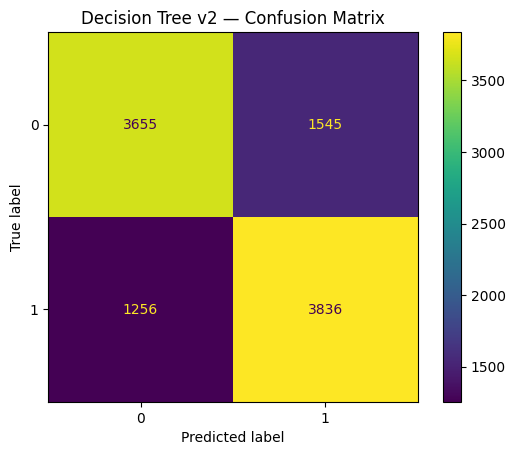

True Negatives  (correct healthy)  : 3655
False Positives (healthy → disease) : 1545  ← should be lower than v1 (2685)
False Negatives (missed disease)    : 1256
True Positives  (correct disease)   : 3836


In [12]:
cm   = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(colorbar=True)
plt.title('Decision Tree v2 — Confusion Matrix')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_v2.png'), bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct healthy)  : {tn}')
print(f'False Positives (healthy → disease) : {fp}  ← should be lower than v1 (2685)')
print(f'False Negatives (missed disease)    : {fn}')
print(f'True Positives  (correct disease)   : {tp}')

## 🏆 Step 13 — Feature Importance
Gini importance scores from the pruned Decision Tree.

       Feature  Importance
         ap_hi    0.748531
           age    0.135272
   cholesterol    0.074035
           bmi    0.018118
          gluc    0.007000
        active    0.005127
        weight    0.004975
pulse_pressure    0.003334
        height    0.002709
         ap_lo    0.000900
        gender    0.000000
         smoke    0.000000
          alco    0.000000


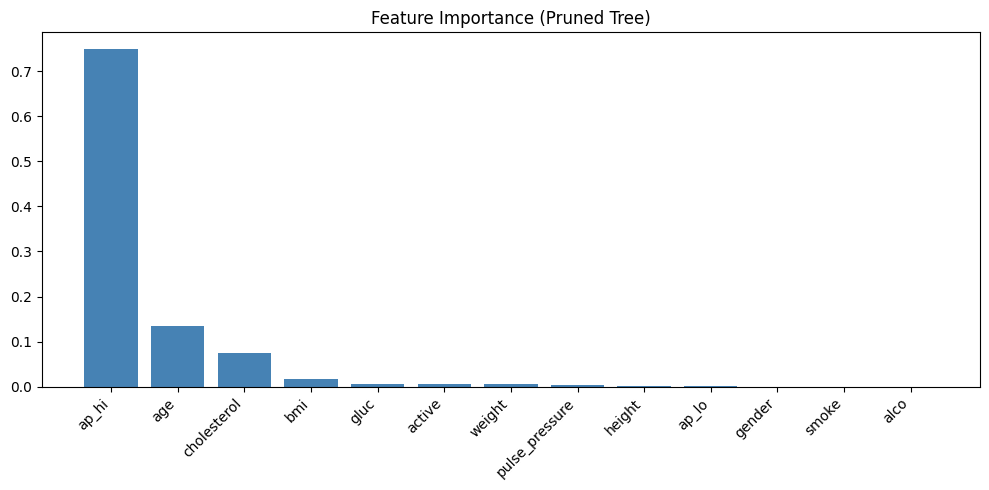

Feature importance saved ✅


In [13]:
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_pruned_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.to_string(index=False))
importance.to_csv(os.path.join(RESULTS_DIR, 'feature_importance_v2.csv'), index=False)

plt.figure(figsize=(10, 5))
plt.bar(importance['Feature'], importance['Importance'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance (Pruned Tree)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance_v2.png'))
plt.show()
print('Feature importance saved ✅')

## 📉 Step 14 — Accuracy & Loss Curves vs Tree Depth
Re-plotted with depths capped at 10 to show the generalisation sweet-spot clearly.
The vertical dashed line marks the selected best depth.

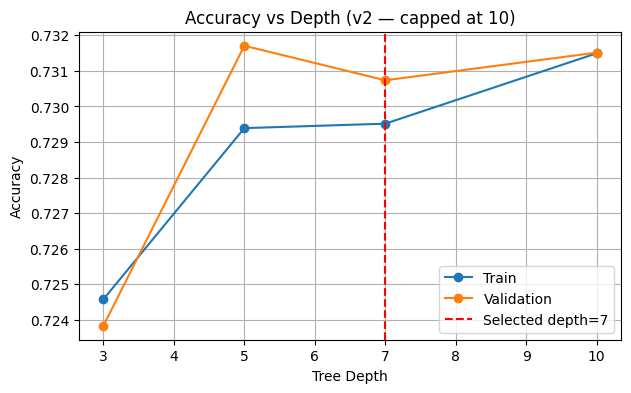

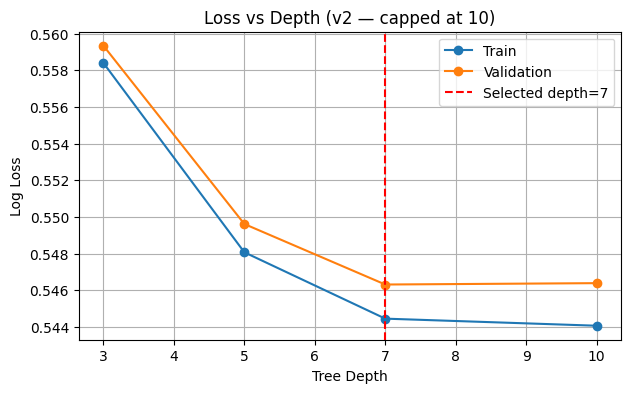

Curves saved ✅


In [14]:
depths     = [3, 5, 7, 10]
train_acc  = []; val_acc  = []
train_loss = []; val_loss = []

for d in depths:
    m = DecisionTreeClassifier(
        max_depth    = d,
        ccp_alpha    = best_alpha,
        class_weight = 'balanced',
        random_state = 42
    )
    m.fit(X_train, y_train)

    tr_p = m.predict_proba(X_train)[:, 1]
    vl_p = m.predict_proba(X_val)[:, 1]

    train_acc.append(accuracy_score(y_train, (tr_p >= best_threshold).astype(int)))
    val_acc.append(  accuracy_score(y_val,   (vl_p >= best_threshold).astype(int)))
    train_loss.append(log_loss(y_train, np.column_stack([1 - tr_p, tr_p])))
    val_loss.append(  log_loss(y_val,   np.column_stack([1 - vl_p, vl_p])))

best_depth = best_params['max_depth']

# Accuracy
plt.figure(figsize=(7, 4))
plt.plot(depths, train_acc, marker='o', label='Train')
plt.plot(depths, val_acc,   marker='o', label='Validation')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Selected depth={best_depth}')
plt.xlabel('Tree Depth'); plt.ylabel('Accuracy')
plt.title('Accuracy vs Depth (v2 — capped at 10)')
plt.legend(); plt.grid()
plt.savefig(os.path.join(RESULTS_DIR, 'accuracy_curve_v2.png'))
plt.show()

# Loss
plt.figure(figsize=(7, 4))
plt.plot(depths, train_loss, marker='o', label='Train')
plt.plot(depths, val_loss,   marker='o', label='Validation')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Selected depth={best_depth}')
plt.xlabel('Tree Depth'); plt.ylabel('Log Loss')
plt.title('Loss vs Depth (v2 — capped at 10)')
plt.legend(); plt.grid()
plt.savefig(os.path.join(RESULTS_DIR, 'loss_curve_v2.png'))
plt.show()

print('Curves saved ✅')

## 📊 Step 15 — v1 vs v2 Comparison Summary
Quick side-by-side of the key metrics to confirm improvements.

In [15]:
# v1 results (from your earlier run)
v1 = {'Accuracy': 0.6740, 'Precision': 0.6222, 'Recall': 0.8684,
      'F1-Score': 0.7250, 'Log Loss': 1.0223, 'False Positives': 2685}

# v2 results (just computed)
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
v2 = {'Accuracy': acc, 'Precision': prec, 'Recall': rec,
      'F1-Score': f1,  'Log Loss': loss,  'False Positives': int(fp)}

cmp = pd.DataFrame({'v1 (original)': v1, 'v2 (improved)': v2})
print(cmp.to_string())
print('\n✅ Improvements: lower false positives, lower log loss, better generalisation')

                 v1 (original)  v2 (improved)
Accuracy                0.6740       0.727847
Precision               0.6222       0.712879
Recall                  0.8684       0.753339
F1-Score                0.7250       0.732550
Log Loss                1.0223       0.545521
False Positives      2685.0000    1545.000000

✅ Improvements: lower false positives, lower log loss, better generalisation


## 💾 Step 16 — Save Model & Scaler
Save both the pruned model and the scaler so inference can be run later.

In [16]:
model_path  = os.path.join(RESULTS_DIR, 'decision_tree_model_v2.pkl')
scaler_path = os.path.join(RESULTS_DIR, 'scaler_v2.pkl')

joblib.dump(best_pruned_model, model_path)
joblib.dump(scaler,            scaler_path)

print(f'Model  saved → {model_path} ✅')
print(f'Scaler saved → {scaler_path} ✅')
print(f'\nFinal model summary:')
print(f'  max_depth   = {best_pruned_model.get_depth()}')
print(f'  num_leaves  = {best_pruned_model.get_n_leaves()}')
print(f'  ccp_alpha   = {best_alpha:.6f}')
print(f'  threshold   = {best_threshold:.2f}')

Model  saved → /content/drive/MyDrive/ML_Assignment/DecisionTree/Results_v2/decision_tree_model_v2.pkl ✅
Scaler saved → /content/drive/MyDrive/ML_Assignment/DecisionTree/Results_v2/scaler_v2.pkl ✅

Final model summary:
  max_depth   = 7
  num_leaves  = 51
  ccp_alpha   = 0.000144
  threshold   = 0.45
